# Comparison of th SSR setups against the CSR baseline setup

This covers all three setups, and analyses the difference in performance.

In [123]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

path = '../../../../playwright/results/core-web-vitals/testrun-8/'

pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.rcParams.update({'font.size': 14})

features = ['navTime', 'totalTime', 'lcp', 'fcp', 'ttfb', 'tbt', 'tti', 'longestTask', 'longTasks', 'nf:init', 'nf:config', 'nf:loaded']

def detect_outliers(df, features, contamination=0.1):
    clf = IsolationForest(contamination=contamination, random_state=42)
    outliers = clf.fit_predict(df[features])
    return outliers == 1

def bootstrap_ci(data1, data2, n_iterations=5000, ci=0.99):
    rng = np.random.default_rng(42)
    diffs = []
    
    for _ in range(n_iterations):
        boot1 = rng.choice(data1, size=len(data1), replace=True)
        boot2 = rng.choice(data2, size=len(data2), replace=True)
        diff = pd.Series(boot1).quantile(0.75) - pd.Series(boot2).quantile(0.75)
        diffs.append(diff)
    
    lower = pd.Series(diffs).quantile((1 - ci) / 2)
    upper = pd.Series(diffs).quantile(1 - ((1 - ci) / 2))
    return lower, upper

## UNTHROTTLED Comparison

The outliers will be removed using the IsolationForest unsupervised model and by removing the first 5 cycles (JVM warmup)

In [124]:
target_features = ['ttfb', 'fcp', 'tti', 'lcp']

dirty_dfs =	{
  "CSR": pd.read_csv(f'{path}2024-12-16T09:36:50.835Z_results-csr.csv', sep=',').iloc[5:],
  "SSRH": pd.read_csv(f'{path}2024-12-15T22:05:17.080Z_results-ssrh.csv', sep=',').iloc[5:],
  "SSRV": pd.read_csv(f'{path}2024-12-17T16:46:34.776Z_results-ssrv-sd.csv', sep=',').iloc[5:],
}

masks = {}
dfs = {}

for name, df in dirty_dfs.items():
    mask = detect_outliers(df, target_features)
    masks[name] = mask
    dfs[name] = df[mask].copy()

### Statistical significance (CSR vs SSRH)

A mann-whitney U-test to discover the statistical significance of the results.

In [125]:
hypothesis = {
    'ttfb': 'greater', 
    'fcp': 'greater', 
    'lcp': 'less'
}

results = pd.DataFrame([
    [metric, 
     hyp, 
     stats.mannwhitneyu(dirty_dfs["SSRH"][metric], 
                        dirty_dfs["CSR"][metric],
                        alternative=hyp)[1],
     dirty_dfs["SSRH"][metric].quantile(0.75),
     dirty_dfs["CSR"][metric].quantile(0.75),
     *bootstrap_ci(dirty_dfs["SSRH"][metric], 
                           dirty_dfs["CSR"][metric])]
    for metric, hyp in hypothesis.items()
], columns=['metric', 'hypothesis', 'p_value',  'ssrh_p75','csr_p75', 'ci_lower', 'ci_upper'])

results['adjusted_p'] = multipletests(results['p_value'], method='bonferroni')[1]
results['significant'] = results['adjusted_p'] < 0.01 

compact_format = lambda x: '%.3e' % x if x < 0.00001 else '%.5f' % x
results['p_value'] = results['p_value'].apply(compact_format)
results['adjusted_p'] = results['adjusted_p'].apply(compact_format)

results

,metric,hypothesis,p_value,ssrh_p75,csr_p75,ci_lower,ci_upper,adjusted_p,significant
0,ttfb,greater,2.482e-165,17.60,3.60,13.63,14.50,7.445e-165,True
1,fcp,greater,2.902e-165,92.10,69.00,22.10,24.48,8.706e-165,True
2,lcp,less,2.906e-165,92.10,137.40,-46.10,-44.12,8.718e-165,True


### Statistical significance (CSR vs SSRV)

A mann-whitney U-test to discover the statistical significance of the results.

In [126]:
hypothesis = {
    'ttfb': 'greater', 
    'fcp': 'greater', 
    'lcp': 'less'
}

results = pd.DataFrame([
    [metric, 
     hyp, 
     stats.mannwhitneyu(dirty_dfs["SSRV"][metric], 
                        dirty_dfs["CSR"][metric],
                        alternative=hyp)[1],
     dirty_dfs["SSRV"][metric].quantile(0.75),
     dirty_dfs["CSR"][metric].quantile(0.75),
     *bootstrap_ci(dirty_dfs["SSRV"][metric], 
                           dirty_dfs["CSR"][metric])]
    for metric, hyp in hypothesis.items()
], columns=['metric', 'hypothesis', 'p_value',  'ssrh_p75','csr_p75', 'ci_lower', 'ci_upper'])

results['adjusted_p'] = multipletests(results['p_value'], method='bonferroni')[1]
results['significant'] = results['adjusted_p'] < 0.01 

compact_format = lambda x: '%.3e' % x if x < 0.00001 else '%.5f' % x
results['p_value'] = results['p_value'].apply(compact_format)
results['adjusted_p'] = results['adjusted_p'].apply(compact_format)

results

,metric,hypothesis,p_value,ssrh_p75,csr_p75,ci_lower,ci_upper,adjusted_p,significant
0,ttfb,greater,2.487e-165,22.60,3.60,18.40,19.63,7.460e-165,True
1,fcp,greater,1.001e-164,88.60,69.00,18.60,21.20,3.003e-164,True
2,lcp,less,2.906e-165,88.80,137.40,-49.43,-46.70,8.717e-165,True


### Comparison of the different metrics

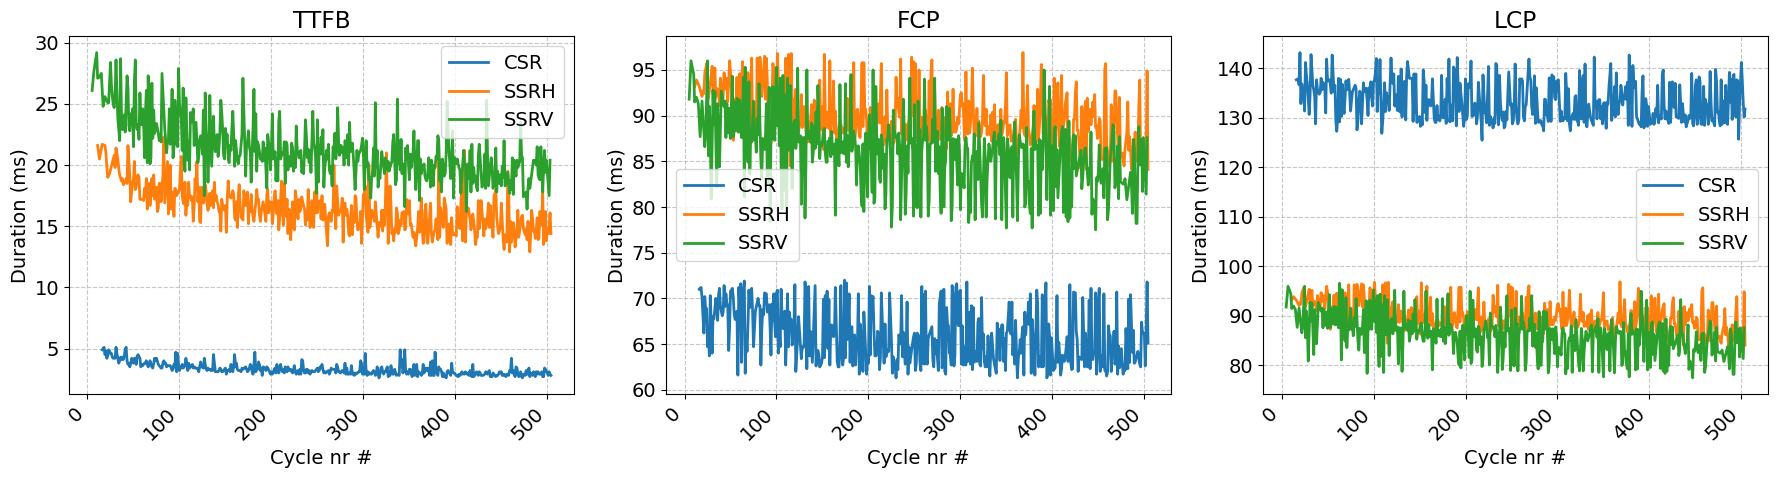

In [127]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
axes = axes.flatten()

for idx, feature in enumerate(['ttfb','fcp','lcp']):
    ax = axes[idx]
    
    for name, df in dfs.items():
        ax.plot(df[feature], 
                label=name, linewidth=2)
    
    ax.set_title(feature.upper())
    ax.set_xlabel('Cycle nr #')
    ax.set_ylabel('Duration (ms)')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

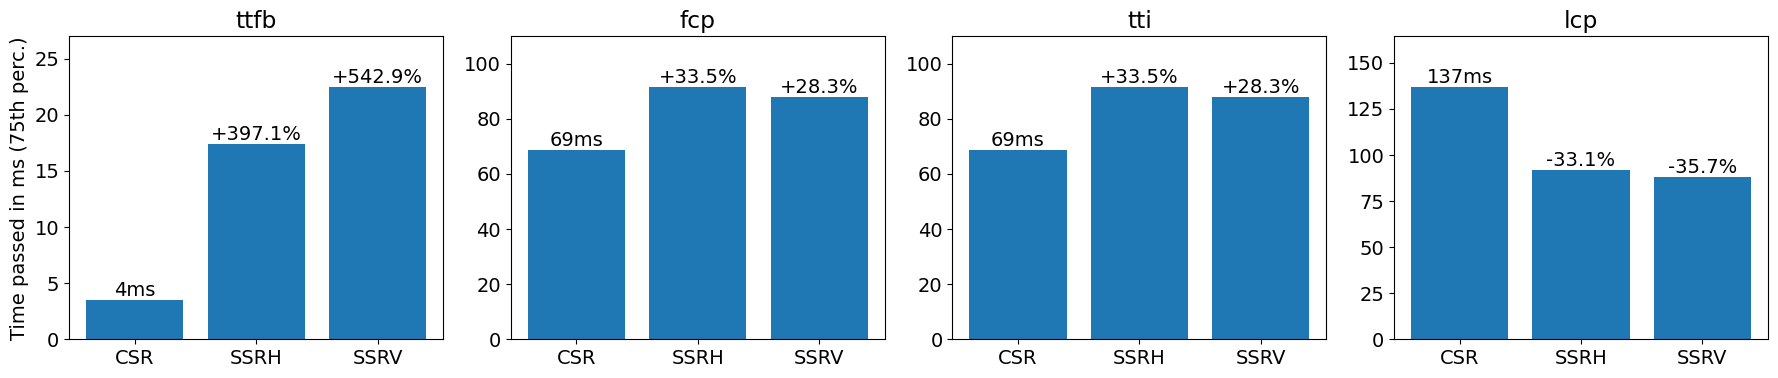

In [128]:
fig, axes = plt.subplots(ncols=len(target_features), figsize=(18, 4))
plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)

for idx, feature in enumerate(target_features):
    percentiles = {d: dfs[d][feature].quantile(0.75) for d in dfs}
    bars = axes[idx].bar(percentiles.keys(), percentiles.values())
    baseline = list(percentiles.values())[0]

    max_height = max(percentiles.values())
    axes[idx].set_ylim(0, max_height * 1.2)
    
    for i, bar in enumerate(bars):
        percentage = ((bar.get_height() / baseline) - 1) * 100
        label = f'{int(round(bar.get_height(), 0))}ms' if (i == 0) else f'{percentage:+.1f}%'
        axes[idx].text(bar.get_x() + bar.get_width()/2., bar.get_height(), label, ha='center', va='bottom')
    
    axes[idx].set_title(feature)
    if idx == 0:
        axes[idx].set_ylabel('Time passed in ms (75th perc.)')

plt.tight_layout()
plt.show()

## THROTTLED Comparison


In [129]:
target_features = ['tbt','ttfb', 'fcp', 'tti', 'lcp']

dirty_dfs =	{
  "CSR": pd.read_csv(f'{path}2024-12-16T11:08:37.924Z_results-csr-throttled.csv', sep=',').iloc[5:],
  "SSRH": pd.read_csv(f'{path}2024-12-15T23:30:49.336Z_results-ssrh-throttled.csv', sep=',').iloc[5:],
  "SSRV": pd.read_csv(f'{path}2024-12-17T18:41:33.545Z_results-ssrv-sd-throttled.csv', sep=',').iloc[5:],
}

masks = {}
dfs = {}

for name, df in dirty_dfs.items():
    mask = detect_outliers(df, target_features)
    masks[name] = mask
    dfs[name] = df[mask].copy()

### Statistical significance (CSR vs SSRH)

A mann-whitney U-test to discover the statistical significance of the results.

In [130]:
hypothesis = {
    'ttfb': 'greater', 
    'fcp': 'greater', 
    'lcp': 'less'
}

results = pd.DataFrame([
    [metric, 
     hyp, 
     stats.mannwhitneyu(dirty_dfs["SSRH"][metric], 
                        dirty_dfs["CSR"][metric],
                        alternative=hyp)[1],
     dirty_dfs["SSRH"][metric].quantile(0.75),
     dirty_dfs["CSR"][metric].quantile(0.75),
     *bootstrap_ci(dirty_dfs["SSRH"][metric], 
                           dirty_dfs["CSR"][metric])]
    for metric, hyp in hypothesis.items()
], columns=['metric', 'hypothesis', 'p_value',  'ssrh_p75','csr_p75', 'ci_lower', 'ci_upper'])

results['adjusted_p'] = multipletests(results['p_value'], method='bonferroni')[1]
results['significant'] = results['adjusted_p'] < 0.01 

compact_format = lambda x: '%.3e' % x if x < 0.00001 else '%.5f' % x
results['p_value'] = results['p_value'].apply(compact_format)
results['adjusted_p'] = results['adjusted_p'].apply(compact_format)

results

,metric,hypothesis,p_value,ssrh_p75,csr_p75,ci_lower,ci_upper,adjusted_p,significant
0,ttfb,greater,2.495e-165,370.60,340.30,30.10,30.50,7.484e-165,True
1,fcp,greater,2.910e-165,1193.90,1135.90,57.00,58.40,8.730e-165,True
2,lcp,less,2.917e-165,1193.90,4553.90,-3365.80,-3359.30,8.751e-165,True


### Statistical significance (CSR vs SSRV)

A mann-whitney U-test to discover the statistical significance of the results.

In [131]:
hypothesis = {
    'ttfb': 'greater', 
    'fcp': 'greater', 
    'lcp': 'less'
}

results = pd.DataFrame([
    [metric, 
     hyp, 
     stats.mannwhitneyu(dirty_dfs["SSRV"][metric], 
                        dirty_dfs["CSR"][metric],
                        alternative=hyp)[1],
     dirty_dfs["SSRV"][metric].quantile(0.75),
     dirty_dfs["CSR"][metric].quantile(0.75),
     *bootstrap_ci(dirty_dfs["SSRV"][metric], 
                           dirty_dfs["CSR"][metric])]
    for metric, hyp in hypothesis.items()
], columns=['metric', 'hypothesis', 'p_value',  'ssrh_p75','csr_p75', 'ci_lower', 'ci_upper'])

results['adjusted_p'] = multipletests(results['p_value'], method='bonferroni')[1]
results['significant'] = results['adjusted_p'] < 0.01 

compact_format = lambda x: '%.3e' % x if x < 0.00001 else '%.5f' % x
results['p_value'] = results['p_value'].apply(compact_format)
results['adjusted_p'] = results['adjusted_p'].apply(compact_format)

results

,metric,hypothesis,p_value,ssrh_p75,csr_p75,ci_lower,ci_upper,adjusted_p,significant
0,ttfb,greater,1.00000,227.10,340.30,-113.50,-112.90,1.00000,False
1,fcp,greater,1.00000,259.30,1135.90,-877.53,-876.20,1.00000,False
2,lcp,less,2.911e-165,1048.03,4553.90,-3511.60,-3504.57,8.733e-165,True


### Comparison of the different metrics

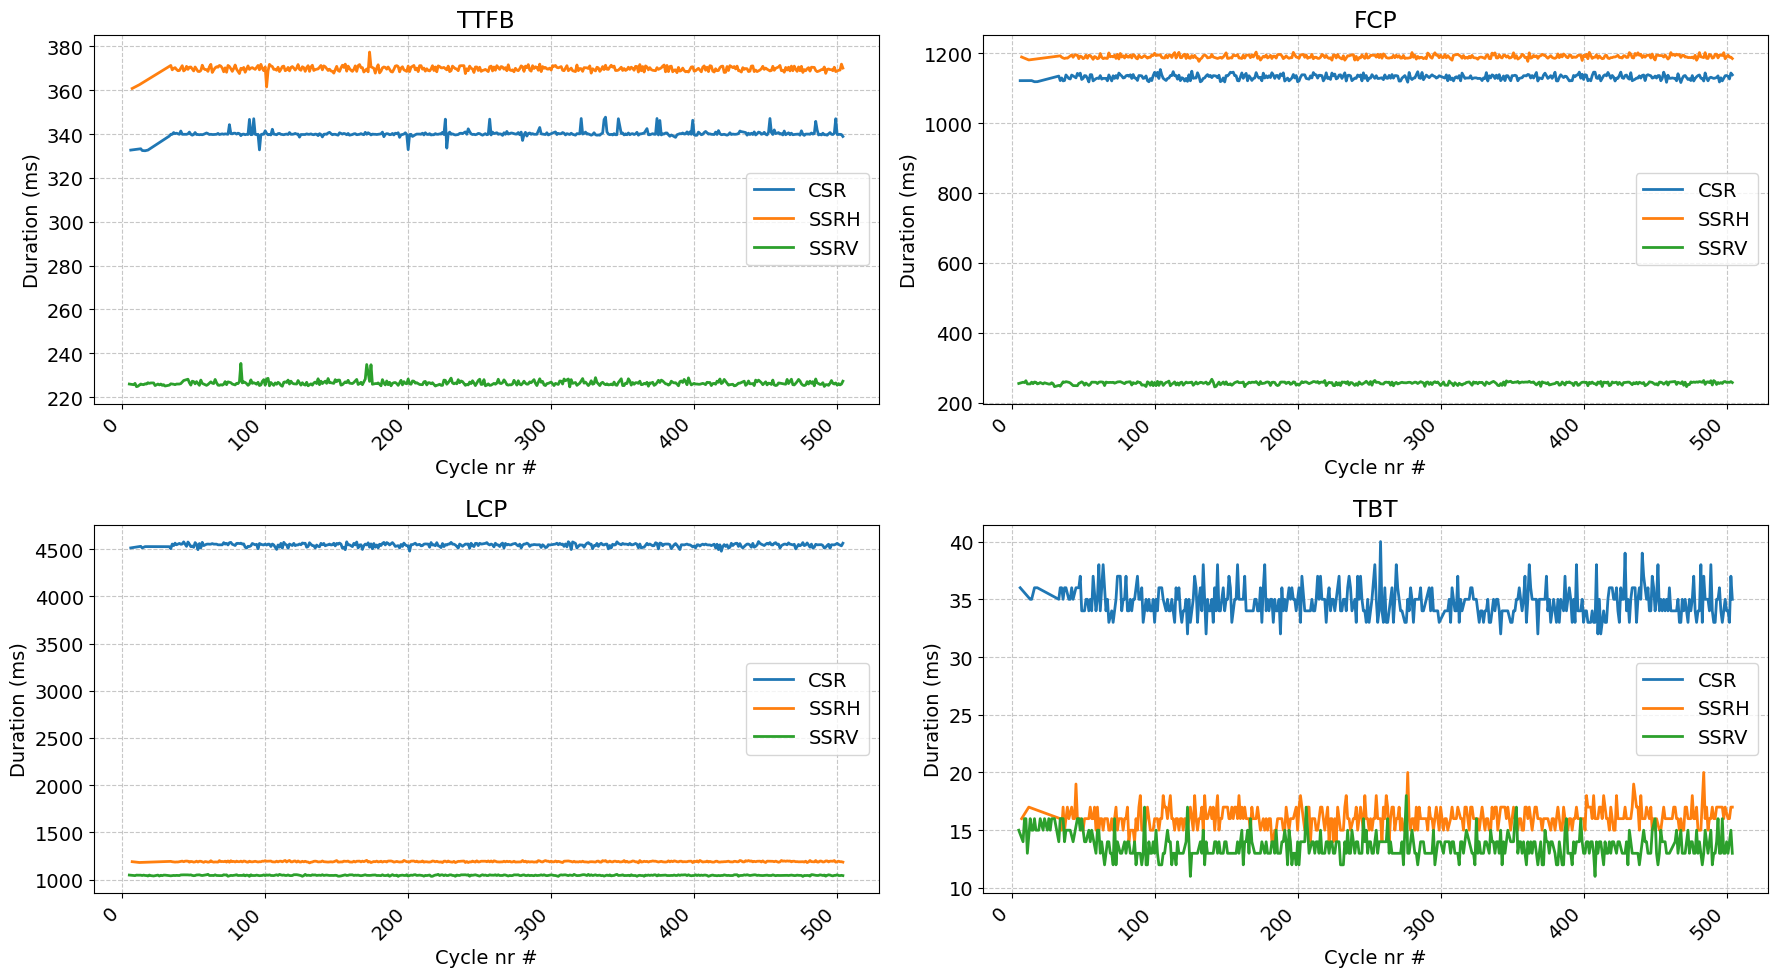

In [132]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18,10))
axes = axes.flatten()

for idx, feature in enumerate(['ttfb','fcp','lcp', 'tbt']):
    ax = axes[idx]
    
    for name, df in dfs.items():
        ax.plot(df[feature], 
                label=name, linewidth=2)
    
    ax.set_title(feature.upper())
    ax.set_xlabel('Cycle nr #')
    ax.set_ylabel('Duration (ms)')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

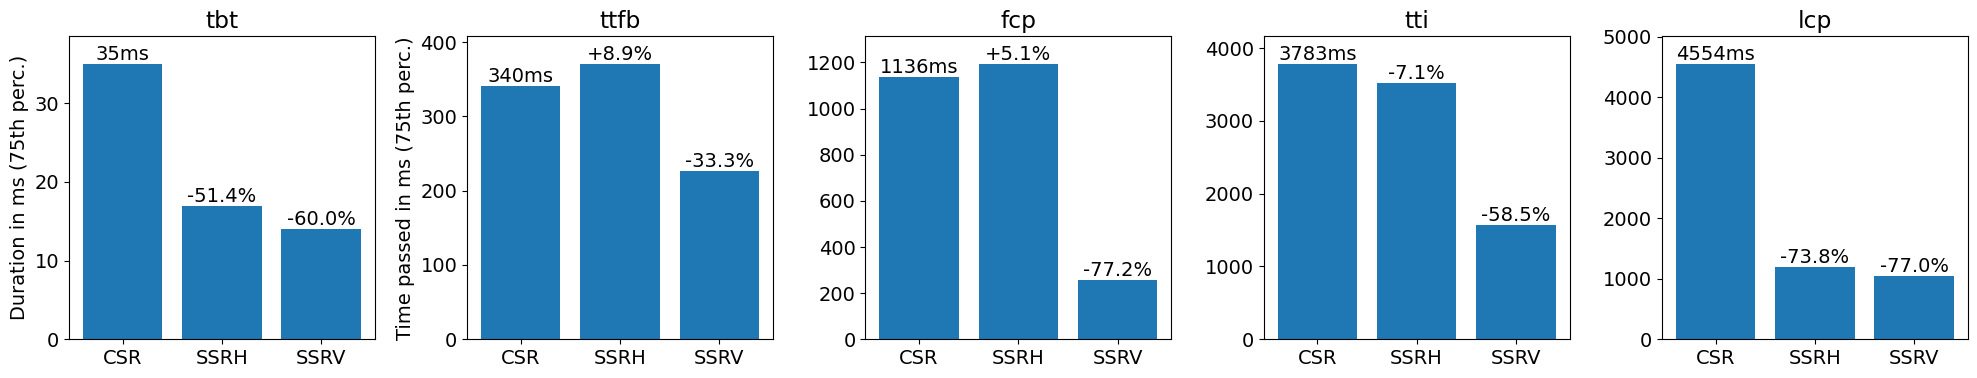

In [133]:
fig, axes = plt.subplots(ncols=len(target_features), figsize=(20, 4))
plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)

for idx, feature in enumerate(target_features):
    percentiles = {d: dfs[d][feature].quantile(0.75) for d in dfs}
    bars = axes[idx].bar(percentiles.keys(), percentiles.values())
    baseline = list(percentiles.values())[0]

    max_height = max(percentiles.values())
    axes[idx].set_ylim(0, max_height * 1.10)
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        percentage = ((height / baseline) - 1) * 100
        label = f'{int(round(height, 0))}ms' if (i == 0) else f'{percentage:+.1f}%'
        axes[idx].text(bar.get_x() + bar.get_width()/2., height, label, ha='center', va='bottom')
    
    axes[idx].set_title(feature)
    if idx == 0:
        axes[idx].set_ylabel('Duration in ms (75th perc.)')
    if idx == 1:
        axes[idx].set_ylabel('Time passed in ms (75th perc.)')

plt.tight_layout()
plt.show()

## HEAVY THROTTLED Comparison

In [134]:
target_features = ['tbt','ttfb', 'fcp', 'tti', 'lcp']

dirty_dfs =	{
  "CSR": pd.read_csv(f'{path}2024-12-16T12:37:45.058Z_results-csr-throttled-heavy.csv', sep=',').iloc[5:],
  "SSRH": pd.read_csv(f'{path}2024-12-16T07:53:32.348Z_results-ssrh-throttled-heavy.csv', sep=',').iloc[5:],
  "SSRV": pd.read_csv(f'{path}2024-12-17T20:20:42.349Z_results-ssrv-sd-throttled-heavy.csv', sep=',').iloc[5:],
}

masks = {}
dfs = {}

for name, df in dirty_dfs.items():
    mask = detect_outliers(df, target_features)
    masks[name] = mask
    dfs[name] = df[mask].copy()

### Statistical significance (CSR vs SSRH)

A mann-whitney U-test to discover the statistical significance of the results.

In [135]:
hypothesis = {
    'ttfb': 'greater', 
    'fcp': 'greater', 
    'lcp': 'less'
}

results = pd.DataFrame([
    [metric, 
     hyp, 
     stats.mannwhitneyu(dirty_dfs["SSRH"][metric], 
                        dirty_dfs["CSR"][metric],
                        alternative=hyp)[1],
     dirty_dfs["SSRH"][metric].quantile(0.75),
     dirty_dfs["CSR"][metric].quantile(0.75),
     *bootstrap_ci(dirty_dfs["SSRH"][metric], 
                           dirty_dfs["CSR"][metric])]
    for metric, hyp in hypothesis.items()
], columns=['metric', 'hypothesis', 'p_value',  'ssrh_p75','csr_p75', 'ci_lower', 'ci_upper'])

results['adjusted_p'] = multipletests(results['p_value'], method='bonferroni')[1]
results['significant'] = results['adjusted_p'] < 0.01 

compact_format = lambda x: '%.3e' % x if x < 0.00001 else '%.5f' % x
results['p_value'] = results['p_value'].apply(compact_format)
results['adjusted_p'] = results['adjusted_p'].apply(compact_format)

results

,metric,hypothesis,p_value,ssrh_p75,csr_p75,ci_lower,ci_upper,adjusted_p,significant
0,ttfb,greater,2.768e-165,371.80,342.43,29.00,29.60,8.303e-165,True
1,fcp,greater,3.026e-165,1265.92,1214.23,47.50,54.20,9.078e-165,True
2,lcp,less,2.923e-165,1265.92,4863.10,-3604.40,-3589.92,8.768e-165,True


### Statistical significance (CSR vs SSRV)

A mann-whitney U-test to discover the statistical significance of the results.

In [136]:
hypothesis = {
    'ttfb': 'greater', 
    'fcp': 'greater', 
    'lcp': 'less'
}

results = pd.DataFrame([
    [metric, 
     hyp, 
     stats.mannwhitneyu(dirty_dfs["SSRV"][metric], 
                        dirty_dfs["CSR"][metric],
                        alternative=hyp)[1],
     dirty_dfs["SSRV"][metric].quantile(0.75),
     dirty_dfs["CSR"][metric].quantile(0.75),
     *bootstrap_ci(dirty_dfs["SSRV"][metric], 
                           dirty_dfs["CSR"][metric])]
    for metric, hyp in hypothesis.items()
], columns=['metric', 'hypothesis', 'p_value',  'ssrh_p75','csr_p75', 'ci_lower', 'ci_upper'])

results['adjusted_p'] = multipletests(results['p_value'], method='bonferroni')[1]
results['significant'] = results['adjusted_p'] < 0.01 

compact_format = lambda x: '%.3e' % x if x < 0.00001 else '%.5f' % x
results['p_value'] = results['p_value'].apply(compact_format)
results['adjusted_p'] = results['adjusted_p'].apply(compact_format)

results

,metric,hypothesis,p_value,ssrh_p75,csr_p75,ci_lower,ci_upper,adjusted_p,significant
0,ttfb,greater,1.00000,228.20,342.43,-114.60,-114.00,1.00000,False
1,fcp,greater,1.00000,345.52,1214.23,-872.60,-866.70,1.00000,False
2,lcp,less,2.926e-165,1101.00,4863.10,-3771.63,-3754.97,8.778e-165,True


### Comparing the different metrics


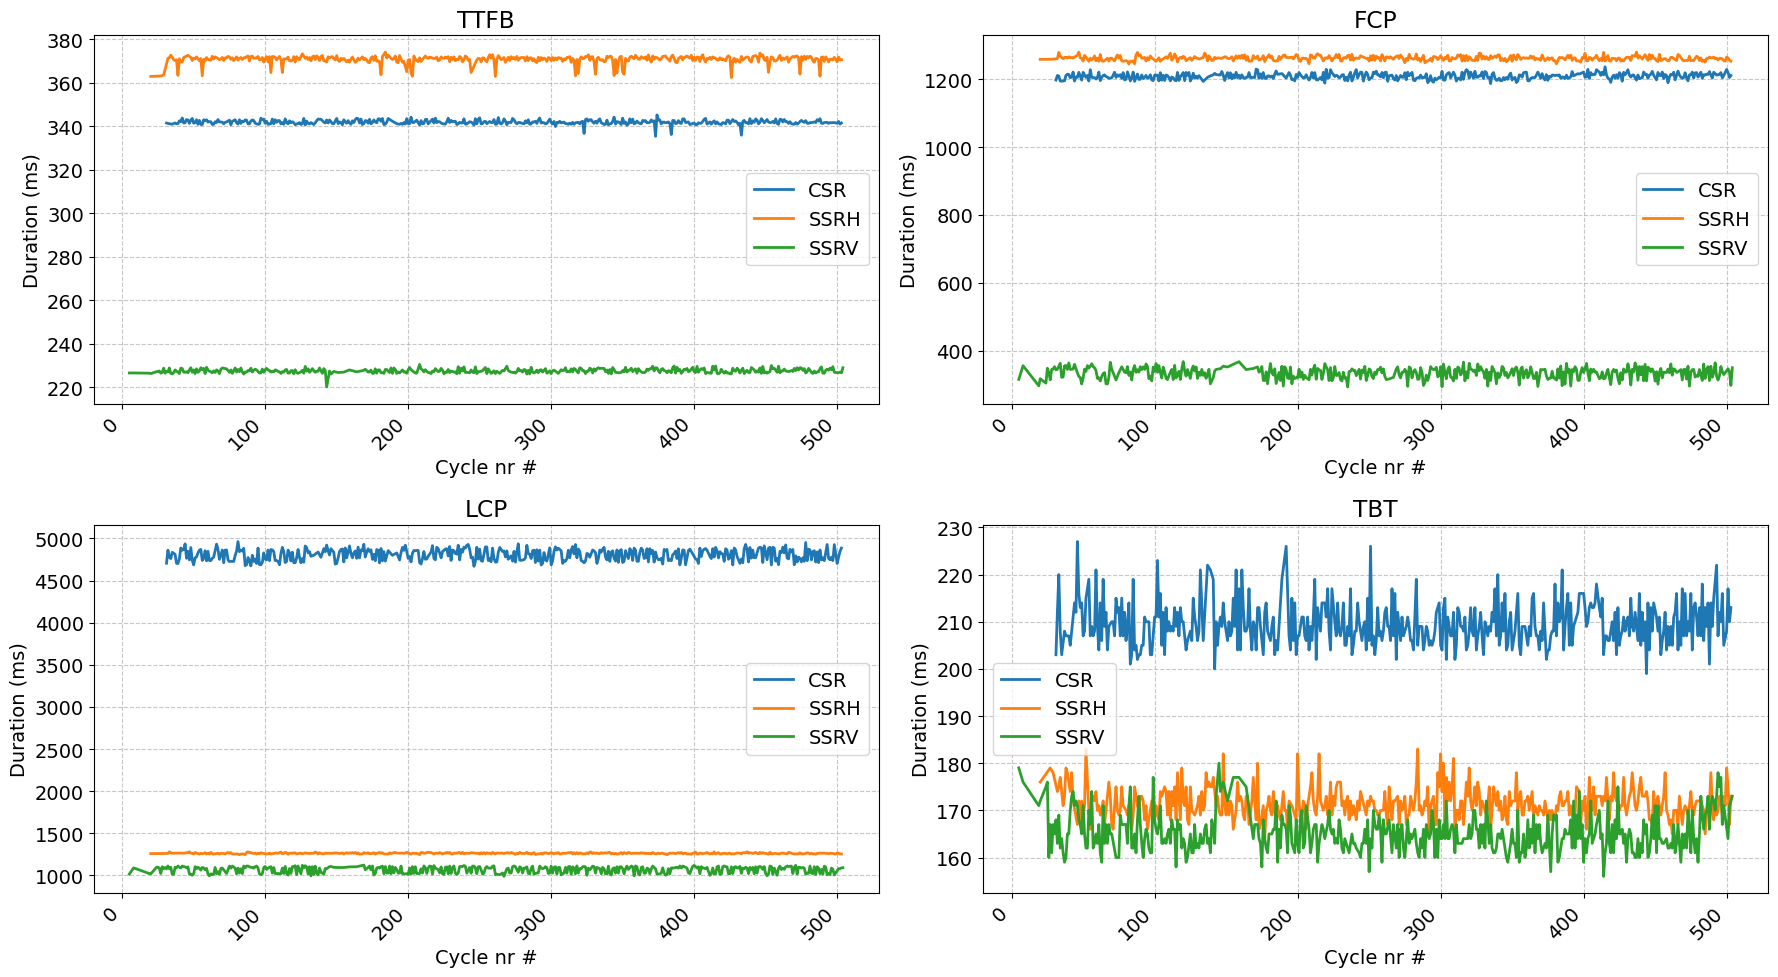

In [137]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(['ttfb','fcp','lcp', 'tbt']):
    ax = axes[idx]
    
    for name, df in dfs.items():
        ax.plot(df[feature], 
                label=name, linewidth=2)
    
    ax.set_title(feature.upper())
    ax.set_xlabel('Cycle nr #')
    ax.set_ylabel('Duration (ms)')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

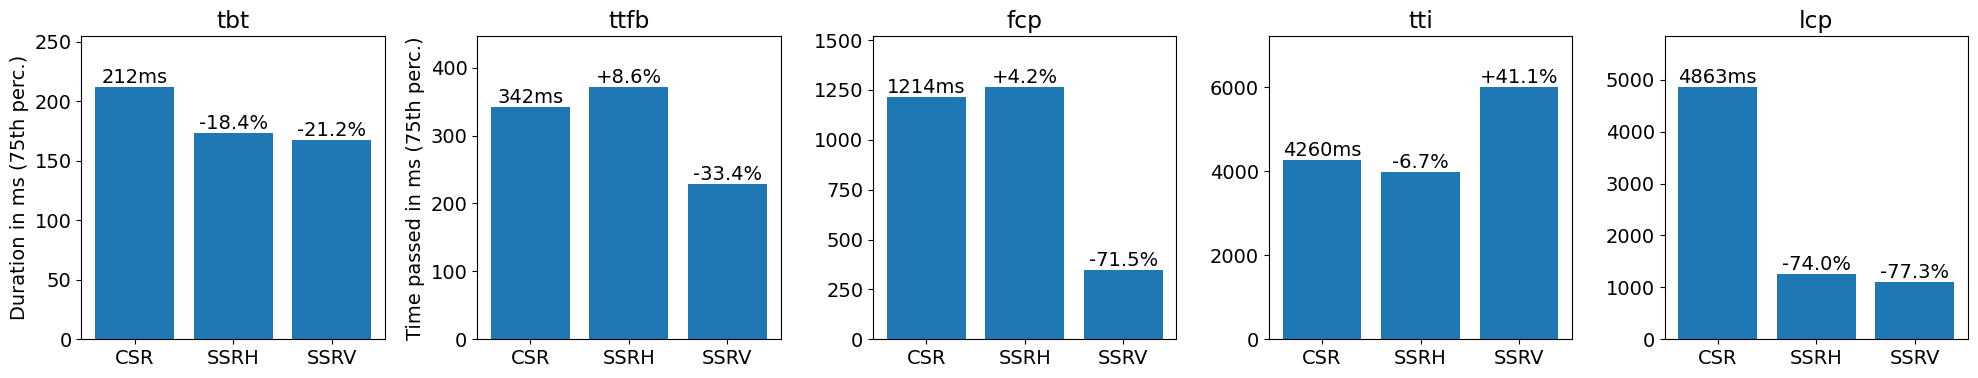

In [138]:
fig, axes = plt.subplots(ncols=len(target_features), figsize=(20, 4))
plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)

for idx, feature in enumerate(target_features):
    percentiles = {d: dfs[d][feature].quantile(0.75) for d in dfs}
    bars = axes[idx].bar(percentiles.keys(), percentiles.values())
    baseline = list(percentiles.values())[0]

    max_height = max(percentiles.values())
    axes[idx].set_ylim(0, max_height * 1.2)
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        percentage = ((height / baseline) - 1) * 100
        label = f'{int(round(height, 0))}ms' if (i == 0) else f'{percentage:+.1f}%'
        axes[idx].text(bar.get_x() + bar.get_width()/2., height, label, ha='center', va='bottom')
    
    axes[idx].set_title(feature)
    if idx == 0:
        axes[idx].set_ylabel('Duration in ms (75th perc.)')
    if idx == 1:
        axes[idx].set_ylabel('Time passed in ms (75th perc.)')

plt.tight_layout()
plt.show()